1. На основе учебного ноутбука проведите финальную подготовку данных. Иизмените количество сегментирующих классов с `16` на `5`.

2. Проведите суммарно не менее `10` экспериментов и визуализируйте их результаты (включая точность обучения сетей на одинаковом количестве эпох, например, на `7`):

  - изменив `filters` в сверточных слоях
  - изменив `kernel_size` в сверточных слоях
  - изменив активационную функцию в скрытых слоях с `relu` на `linear` или/и `selu`, `elu`.


**Важно!**

Многие эксперименты могут приводить к переполнению ОЗУ в вашем ноутбуке и сброса кода обучения.

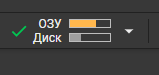



Для предотвращения переполнения ОЗУ может помочь библиотека `gc`. Вставьте строчку `gc.collect()` в цикл ваших экспериментов для сбора и удаления временных данных (кеш).

Перед выполнением задания, пожалуйста, запустите ячейку `Подготовка` ниже:

## Подготовка

### Импорт библиотек

In [1]:
 # Импортируем модели keras: Model
from tensorflow.keras.models import Model

 # Импортируем стандартные слои keras
from tensorflow.keras.layers import Input, Conv2DTranspose, concatenate, Activation
from tensorflow.keras.layers import MaxPooling2D, Conv2D, BatchNormalization, UpSampling2D

# Импортируем оптимизатор Adam
from tensorflow.keras.optimizers import Adam

# Импортируем модуль pyplot библиотеки matplotlib для построения графиков
import matplotlib.pyplot as plt

# Импортируем модуль image для работы с изображениями
from tensorflow.keras.preprocessing import image

# Импортируем библиотеку numpy
import numpy as np

# Импортируем методделения выборки
from sklearn.model_selection import train_test_split

# загрузка файлов по HTML ссылке
import gdown

# Для работы с файлами
import os

# Для генерации случайных чисел
import random

import time

# импортируем модель Image для работы с изображениями
from PIL import Image

# очистка ОЗУ
import gc

### Загрузка датасета

грузим и распаковываем архив картинок

In [2]:
# Загрузка датасета из облака

gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_256x192.zip', None, quiet=False)
#gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_512x384.zip', None, quiet=False)

!unzip -qo 'construction_256x192.zip' # распоковываем архив

Downloading...
From: https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_256x192.zip
To: /content/construction_256x192.zip
100%|██████████| 214M/214M [00:09<00:00, 21.6MB/s]


In [3]:
# Глобальные параметры

IMG_WIDTH = 192               # Ширина картинки
IMG_HEIGHT = 256              # Высота картинки
NUM_CLASSES = 16              # Задаем количество классов на изображении
TRAIN_DIRECTORY = 'train'     # Название папки с файлами обучающей выборки
VAL_DIRECTORY = 'val'         # Название папки с файлами проверочной выборки

Загрузим оригинальные изображения (код из лекции):

In [4]:
train_images = [] # Создаем пустой список для хранений оригинальных изображений обучающей выборки
val_images = [] # Создаем пустой список для хранений оригинальных изображений проверочной выборки

cur_time = time.time()  # Засекаем текущее время

# Проходим по всем файлам в каталоге по указанному пути
for filename in sorted(os.listdir(TRAIN_DIRECTORY+'/original')):
    # Читаем очередную картинку и добавляем ее в список изображений с указанным target_size
    train_images.append(image.load_img(os.path.join(TRAIN_DIRECTORY+'/original',filename),
                                       target_size=(IMG_WIDTH, IMG_HEIGHT)))

# Отображаем время загрузки картинок обучающей выборки
print ('Обучающая выборка загружена. Время загрузки: ', round(time.time() - cur_time, 2), 'c', sep='')

# Отображаем количество элементов в обучающей выборке
print ('Количество изображений: ', len(train_images))

cur_time = time.time() # Засекаем текущее время

# Проходим по всем файлам в каталоге по указанному пути
for filename in sorted(os.listdir(VAL_DIRECTORY+'/original')):
    # Читаем очередную картинку и добавляем ее в список изображений с указанным target_size
    val_images.append(image.load_img(os.path.join(VAL_DIRECTORY+'/original',filename),
                                     target_size=(IMG_WIDTH, IMG_HEIGHT)))

# Отображаем время загрузки картинок проверочной выборки
print ('Проверочная выборка загружена. Время загрузки: ', round(time.time() - cur_time, 2), 'c', sep='')

# Отображаем количество элементов в проверочной выборке
print ('Количество изображений: ', len(val_images))

Обучающая выборка загружена. Время загрузки: 0.3c
Количество изображений:  1900
Проверочная выборка загружена. Время загрузки: 0.02c
Количество изображений:  100


Загрузим сегментированные изображения (код из лекции):

In [5]:
train_segments = [] # Создаем пустой список для хранений оригинальных изображений обучающей выборки
val_segments = [] # Создаем пустой список для хранений оригинальных изображений проверочной выборки

cur_time = time.time() # Засекаем текущее время

for filename in sorted(os.listdir(TRAIN_DIRECTORY+'/segment')): # Проходим по всем файлам в каталоге по указанному пути
    # Читаем очередную картинку и добавляем ее в список изображений с указанным target_size
    train_segments.append(image.load_img(os.path.join(TRAIN_DIRECTORY+'/segment',filename),
                                       target_size=(IMG_WIDTH, IMG_HEIGHT)))

# Отображаем время загрузки картинок обучающей выборки
print ('Обучающая выборка загружена. Время загрузки: ', round(time.time() - cur_time, 2), 'c', sep='')

# Отображаем количество элементов в обучающем наборе сегментированных изображений
print ('Количество изображений: ', len(train_segments))

cur_time = time.time() # Засекаем текущее время

for filename in sorted(os.listdir(VAL_DIRECTORY+'/segment')): # Проходим по всем файлам в каталоге по указанному пути
    # Читаем очередную картинку и добавляем ее в список изображений с указанным target_size
    val_segments.append(image.load_img(os.path.join(VAL_DIRECTORY+'/segment',filename),
                                     target_size=(IMG_WIDTH, IMG_HEIGHT)))

# Отображаем время загрузки картинок проверочной выборки
print ('Проверочная выборка загружена. Время загрузки: ', round(time.time() - cur_time, 2), 'c', sep='')

# Отображаем количество элементов в проверочном наборе сегментированных изображений
print ('Количество изображений: ', len(val_segments))

Обучающая выборка загружена. Время загрузки: 0.36c
Количество изображений:  1900
Проверочная выборка загружена. Время загрузки: 0.02c
Количество изображений:  100


## Решение


In [6]:
# Ваше решение

In [8]:
from tensorflow.keras import backend as K
import pandas as pd

NUM_CLASSES = 5
EPOCHS = 7
BATCH_SIZE = 4

# ---------- Подготовка данных ----------

def img_to_array_norm(img):
    return image.img_to_array(img).astype("float32") / 255.0

x_train = np.array([img_to_array_norm(img) for img in train_images])
x_val = np.array([img_to_array_norm(img) for img in val_images])

def masks_to_class_ids(masks):
    arrays = [np.array(m) for m in masks]

    # Если маска RGB, кодируем каждый уникальный цвет как отдельный класс
    if arrays[0].ndim == 3:
        pixels = np.concatenate([a.reshape(-1, a.shape[-1]) for a in arrays], axis=0)
        colors = np.unique(pixels, axis=0)
        color_to_id = {tuple(c): i for i, c in enumerate(colors)}

        result = []
        for a in arrays:
            h, w, _ = a.shape
            flat = a.reshape(-1, a.shape[-1])
            ids = np.array([color_to_id[tuple(p)] for p in flat], dtype=np.uint8)
            result.append(ids.reshape(h, w))
        return np.array(result)

    # Если маска уже одноканальная
    return np.array(arrays).astype(np.uint8)

y_train_old = masks_to_class_ids(train_segments)
y_val_old = masks_to_class_ids(val_segments)

# Переводим классы 0..8 -> 0..4
class_map_5 = {
    0: 0,   # FLOOR
    1: 0,   # CEILING

    2: 1,   # WALL

    3: 2,   # APERTURE
    4: 2,   # DOOR
    5: 2,   # WINDOW

    6: 3,   # COLUMN
    7: 3,   # RAILINGS
    8: 3,   # LADDER

    9: 4,   # INVENTORY
    10: 4,  # LAMP
    11: 4,  # WIRE
    12: 4,  # BEAM
    13: 4,  # EXTERNAL
    14: 4,  # BATTERY
    15: 4   # PEOPLE
}
y_train = np.zeros_like(y_train_old)
y_val = np.zeros_like(y_val_old)

for old_class, new_class in class_map_5.items():
    y_train[y_train_old == old_class] = new_class
    y_val[y_val_old == old_class] = new_class

y_train = y_train.astype("uint8")
y_val = y_val.astype("uint8")

print(x_train.shape, y_train.shape)
print(x_val.shape, y_val.shape)

print("Классы после преобразования train:", np.unique(y_train))
print("Классы после преобразования val:", np.unique(y_val))

(1900, 192, 256, 3) (1900, 192, 256)
(100, 192, 256, 3) (100, 192, 256)
Классы после преобразования train: [0 1 2 3 4]
Классы после преобразования val: [0 1 2 3 4]


In [9]:
def build_unet(filters=16, kernel_size=3, activation="relu"):
    inputs = Input((IMG_WIDTH, IMG_HEIGHT, 3))

    c1 = Conv2D(filters, kernel_size, padding="same", activation=activation)(inputs)
    c1 = BatchNormalization()(c1)
    c1 = Conv2D(filters, kernel_size, padding="same", activation=activation)(c1)
    p1 = MaxPooling2D()(c1)

    c2 = Conv2D(filters * 2, kernel_size, padding="same", activation=activation)(p1)
    c2 = BatchNormalization()(c2)
    c2 = Conv2D(filters * 2, kernel_size, padding="same", activation=activation)(c2)
    p2 = MaxPooling2D()(c2)

    c3 = Conv2D(filters * 4, kernel_size, padding="same", activation=activation)(p2)
    c3 = BatchNormalization()(c3)

    u2 = UpSampling2D()(c3)
    u2 = concatenate([u2, c2])
    c4 = Conv2D(filters * 2, kernel_size, padding="same", activation=activation)(u2)

    u1 = UpSampling2D()(c4)
    u1 = concatenate([u1, c1])
    c5 = Conv2D(filters, kernel_size, padding="same", activation=activation)(u1)

    outputs = Conv2D(NUM_CLASSES, 1, padding="same", activation="softmax")(c5)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model



In [10]:

experiments = [
    {"name": "F8_K3_relu",    "filters": 8,  "kernel_size": 3, "activation": "relu"},
    {"name": "F16_K3_relu",   "filters": 16, "kernel_size": 3, "activation": "relu"},
    {"name": "F24_K3_relu",   "filters": 24, "kernel_size": 3, "activation": "relu"},
    {"name": "F32_K3_relu",   "filters": 32, "kernel_size": 3, "activation": "relu"},

    {"name": "F16_K2_relu",   "filters": 16, "kernel_size": 2, "activation": "relu"},
    {"name": "F16_K5_relu",   "filters": 16, "kernel_size": 5, "activation": "relu"},
    {"name": "F16_K7_relu",   "filters": 16, "kernel_size": 7, "activation": "relu"},

    {"name": "F16_K3_linear", "filters": 16, "kernel_size": 3, "activation": "linear"},
    {"name": "F16_K3_selu",   "filters": 16, "kernel_size": 3, "activation": "selu"},
    {"name": "F16_K3_elu",    "filters": 16, "kernel_size": 3, "activation": "elu"},
]

results = []
histories = {}


In [11]:
for exp in experiments:
    print("\nЭксперимент:", exp["name"])

    K.clear_session()
    gc.collect()

    model = build_unet(
        filters=exp["filters"],
        kernel_size=exp["kernel_size"],
        activation=exp["activation"]
    )

    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1
    )

    histories[exp["name"]] = history.history

    results.append({
        "experiment": exp["name"],
        "filters": exp["filters"],
        "kernel_size": exp["kernel_size"],
        "activation": exp["activation"],
        "train_accuracy": history.history["accuracy"][-1],
        "val_accuracy": history.history["val_accuracy"][-1],
        "train_loss": history.history["loss"][-1],
        "val_loss": history.history["val_loss"][-1],
    })

    del model
    K.clear_session()
    gc.collect()


Эксперимент: F8_K3_relu
Epoch 1/7
475/475 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.4957 - loss: 1.2030 - val_accuracy: 0.4922 - val_loss: 1.1543
Epoch 2/7
475/475 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.5641 - loss: 1.0437 - val_accuracy: 0.4995 - val_loss: 1.1186
Epoch 3/7
475/475 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.5825 - loss: 0.9959 - val_accuracy: 0.5304 - val_loss: 1.0676
Epoch 4/7
475/475 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.6047 - loss: 0.9524 - val_accuracy: 0.5122 - val_loss: 1.0781
Epoch 5/7
475/475 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.6210 - loss: 0.9199 - val_accuracy: 0.5341 - val_loss: 1.0689
Epoch 6/7
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.6313 - loss: 0.9015 - val_accuracy: 0.5413 - val_loss: 1.0499
Epoch 7/7
475/475 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.6403 - loss: 0.8849 - val_accuracy: 0.5432 - val_loss: 1.0501

Эксперимент: F16_K3_relu
Epoch 1/7
475/475 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/ste

In [12]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("val_accuracy", ascending=False)
display(results_df)



,experiment,filters,kernel_size,activation,train_accuracy,val_accuracy,train_loss,val_loss
6,F16_K7_relu,16,7,relu,0.765615,0.642616,0.607959,0.881226
5,F16_K5_relu,16,5,relu,0.735310,0.638301,0.677613,0.903408
3,F32_K3_relu,32,3,relu,0.720451,0.600050,0.706227,0.949884
2,F24_K3_relu,24,3,relu,0.701183,0.581257,0.750443,0.990893
1,F16_K3_relu,16,3,relu,0.678623,0.574905,0.799611,0.992240
9,F16_K3_elu,16,3,elu,0.664396,0.569681,0.831610,1.009247
8,F16_K3_selu,16,3,selu,0.644460,0.553921,0.888564,1.035678
7,F16_K3_linear,16,3,linear,0.617786,0.552708,0.936012,1.086378
0,F8_K3_relu,8,3,relu,0.640320,0.543222,0.884901,1.050110
4,F16_K2_relu,16,2,relu,0.634273,0.523586,0.901229,1.086992


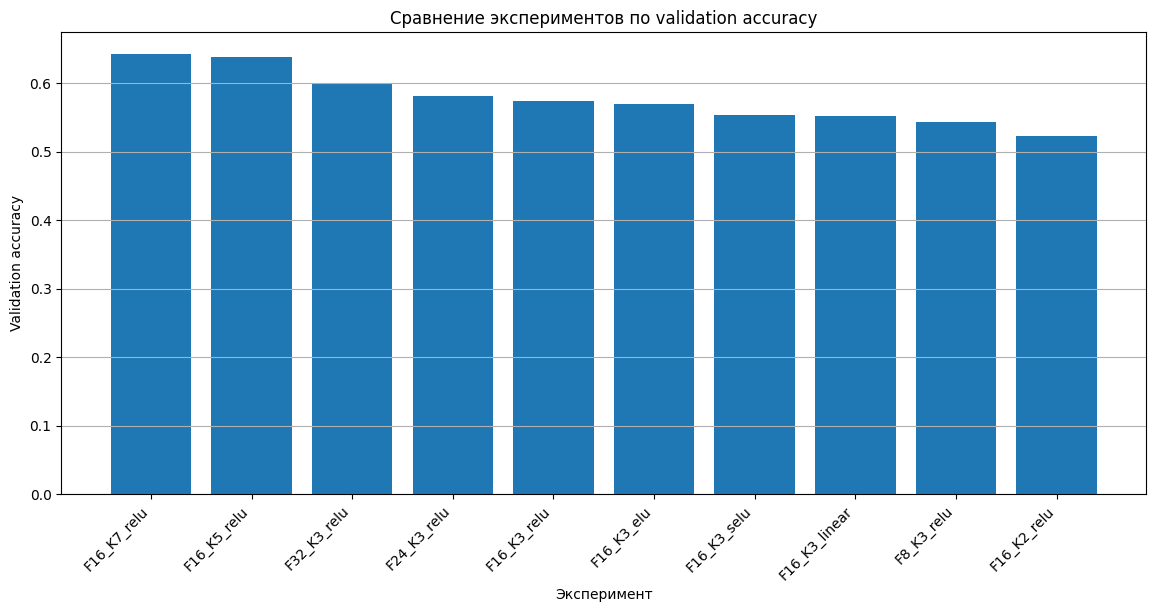

In [13]:
plt.figure(figsize=(14, 6))
plt.bar(results_df["experiment"], results_df["val_accuracy"])
plt.xticks(rotation=45, ha="right")
plt.title("Сравнение экспериментов по validation accuracy")
plt.xlabel("Эксперимент")
plt.ylabel("Validation accuracy")
plt.grid(axis="y")
plt.show()


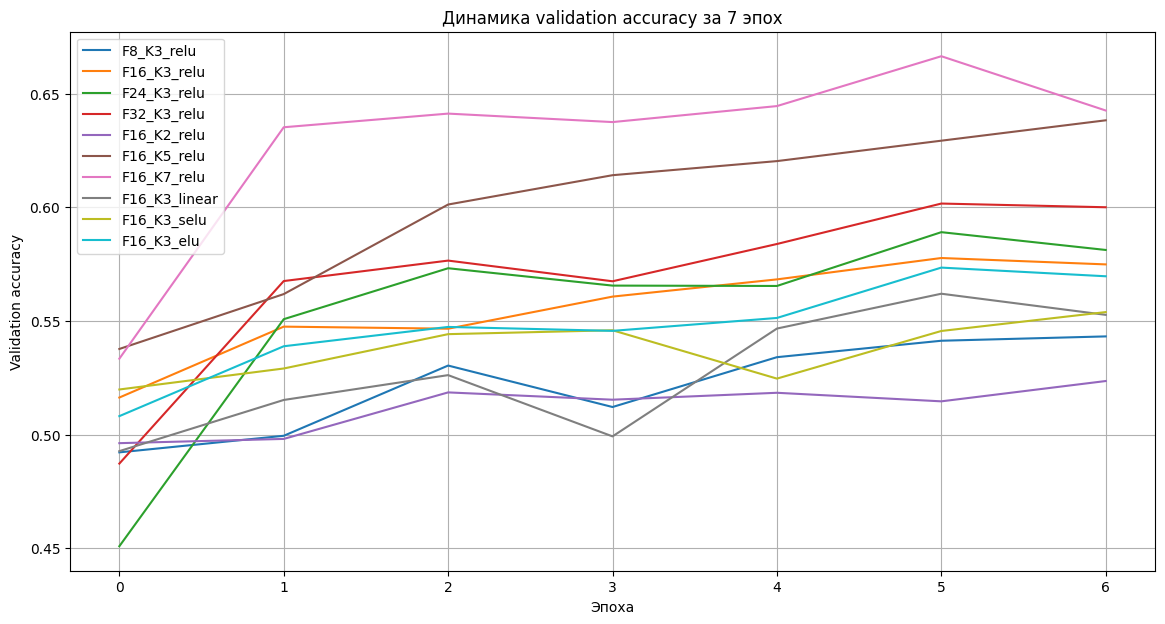

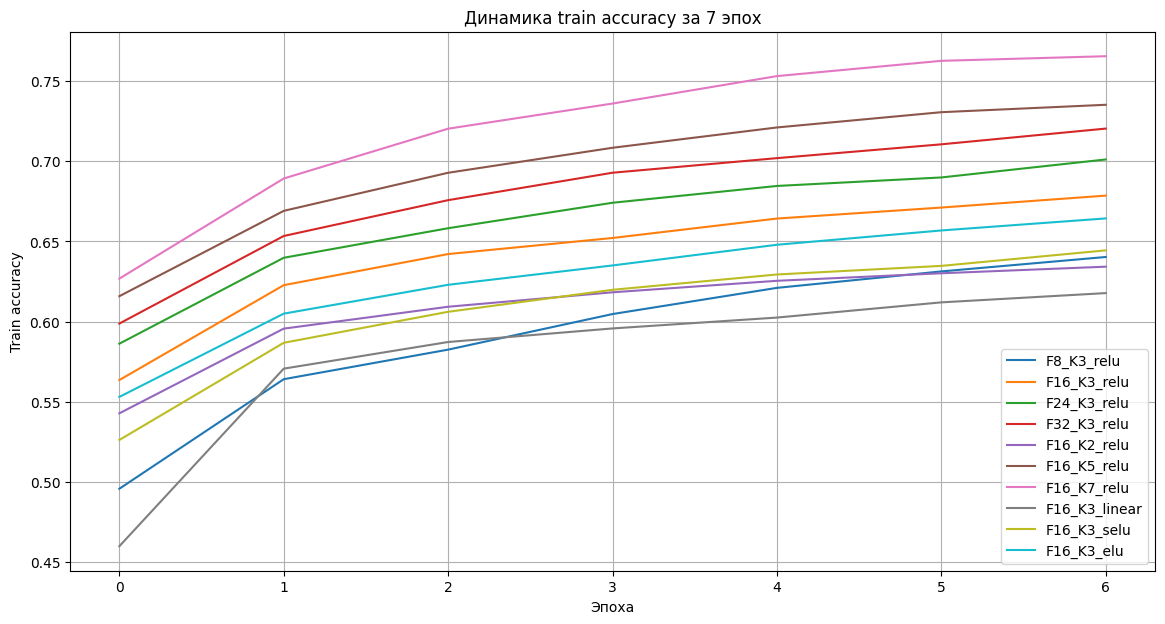

In [14]:
plt.figure(figsize=(14, 7))

for name, hist in histories.items():
    plt.plot(hist["val_accuracy"], label=name)
plt.title("Динамика validation accuracy за 7 эпох")
plt.xlabel("Эпоха")
plt.ylabel("Validation accuracy")
plt.legend()
plt.grid()
plt.show()


plt.figure(figsize=(14, 7))

for name, hist in histories.items():
    plt.plot(hist["accuracy"], label=name)

plt.title("Динамика train accuracy за 7 эпох")
plt.xlabel("Эпоха")
plt.ylabel("Train accuracy")
plt.legend()
plt.grid()
plt.show()

In [15]:
print(np.unique(y_train))
print(np.unique(y_val))
print(np.isnan(x_train).sum(), np.isnan(y_train).sum())
print(x_train.min(), x_train.max())

[0 1 2 3 4]
[0 1 2 3 4]
0 0
0.0 1.0
